In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Dataset Description. This information is on individuals and medical insurance costs in the United States. Demographic and health-related data, such as age as well as sex, body mass index (BMI), number of children, smoking, and local residence are included. The target variable is a number of medical charges charged by health insurance. Such dataset can be used as an exploratory data analysis, in order to comprehend all the factors that affect medical costs.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import os
os.listdir()

['.virtual_documents']

In [8]:
import os
os.listdir("/kaggle/input")


['datasets', 'insurance']

In [22]:
df = pd.read_csv("/kaggle/input/insurance/insurance.csv")

df.head(7)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960


In [23]:
# Check data types
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [24]:
# Convert categorical columns
categorical_cols = ['sex', 'smoker', 'region']
for col in categorical_cols:
    df[col] = df[col].astype('category')

df.dtypes

age            int64
sex         category
bmi          float64
children       int64
smoker      category
region      category
charges      float64
dtype: object

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [11]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [12]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [13]:
df.select_dtypes(include='object').nunique()

sex       2
smoker    2
region    4
dtype: int64

In [14]:
for col in df.select_dtypes(include='object'):
    print(col)
    print(df[col].value_counts())
    print("-"*30)

sex
sex
male      676
female    662
Name: count, dtype: int64
------------------------------
smoker
smoker
no     1064
yes     274
Name: count, dtype: int64
------------------------------
region
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64
------------------------------


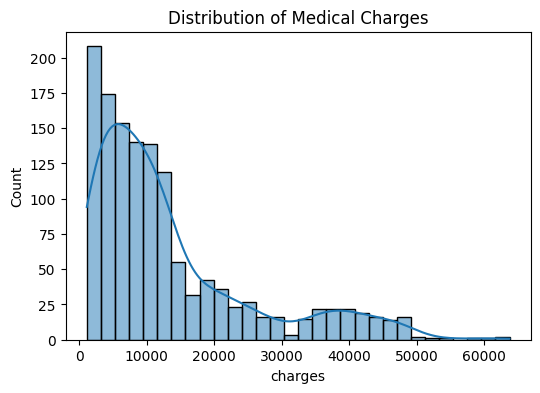

In [15]:
plt.figure(figsize=(6,4))
sns.histplot(df['charges'], kde=True)
plt.title("Distribution of Medical Charges")
plt.show()

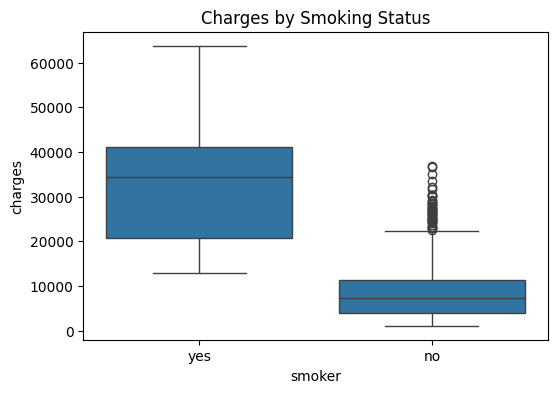

In [16]:
plt.figure(figsize=(6,4))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Charges by Smoking Status")
plt.show()

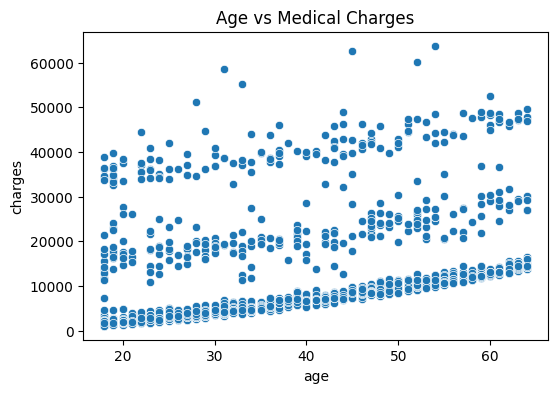

In [17]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='age', y='charges', data=df)
plt.title("Age vs Medical Charges")
plt.show()

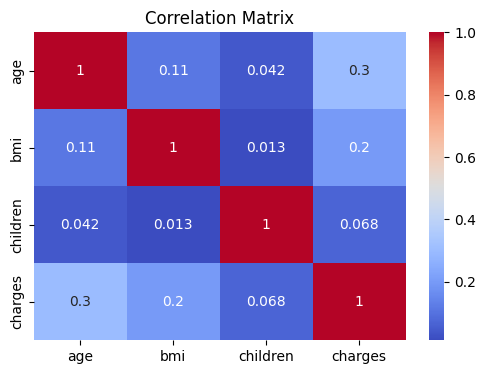

In [19]:
plt.figure(figsize=(6,4))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

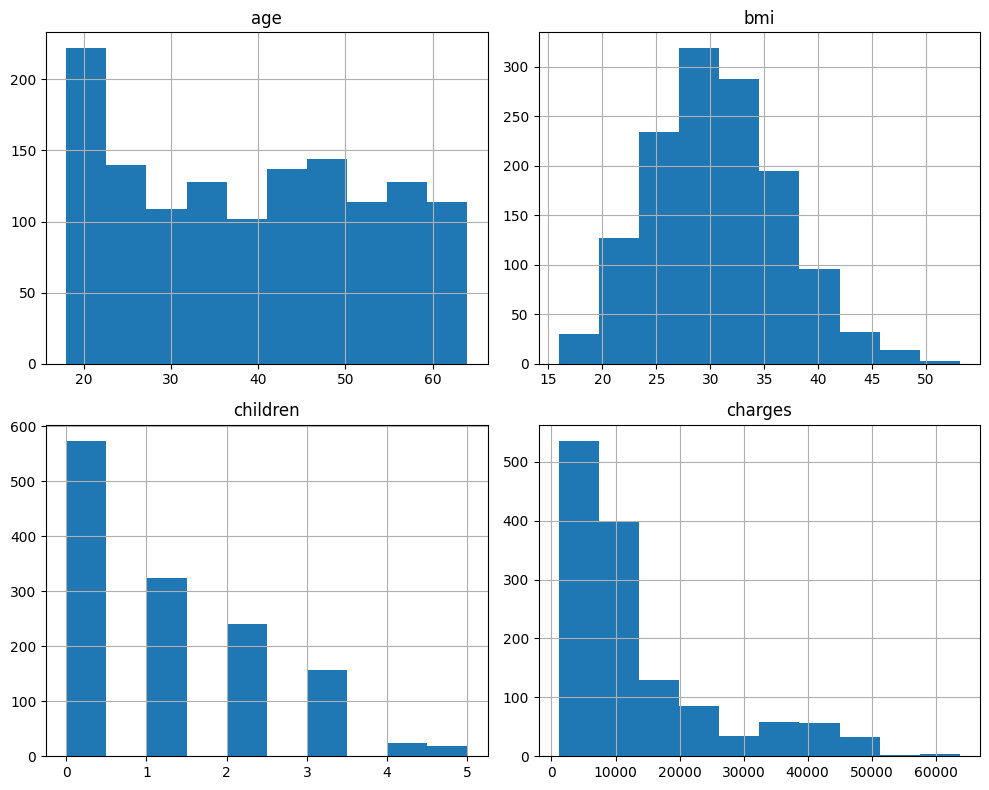

In [20]:
df.hist(figsize=(10,8))
plt.tight_layout()
plt.show()

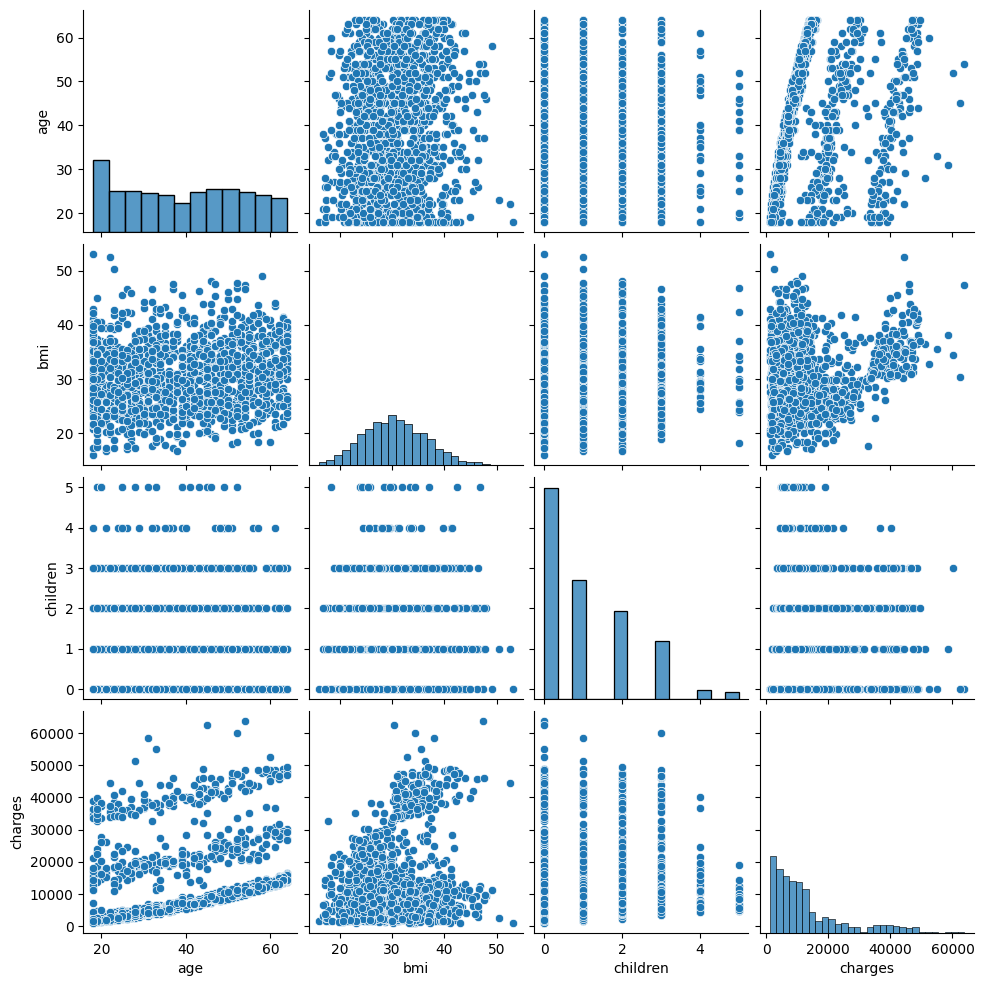

In [21]:
sns.pairplot(df)
plt.show()

EDA Summary. Exploratory data analysis was performed with the Medical insurance dataset to investigate the composition, distributions, and associations of variables. An aggregate of demographic and health information concerning individuals and their medical insurance fees is present. The data set was clean as there were no missing values. Statistical summaries and visualizations were employed to explore numerical and categorical variables. We found some relationships between features and medical charges.